<a href="https://colab.research.google.com/github/Norah-444/Machine-Learning-Project/blob/main/IT461_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Project

# Fashion-MNIST Classification Using Machine Learning
**Course:** IT 461 – Practical Machine Learning  
**University:** King Saud University  
**Semester:** 2, 1447H  
**Supervised by:** Dr. Afshan Jafri  

**Team Members:**
| Name | ID |
|------|----|
| Rana Khalil Alngashy | 444204737 |
| Ghalia Saad Alkhaldi | 444200534 |
| Layan Alhowaimel | 444200969 |
| Norah Riyadh Aljayan | 444200832 |

---

## Project Description
This project applies and compares four supervised machine learning models —
**K-Nearest Neighbors (KNN)**, **Support Vector Machine with RBF kernel (SVM-RBF)**,
**Support Vector Machine with Polynomial kernel (SVM-Poly)**, and a
**Convolutional Neural Network (CNN)** — to classify grayscale fashion images
from the Fashion-MNIST dataset into 10 distinct categories.

## Task
Given a 28×28 grayscale image of a fashion item (784 pixel features), predict
its category from 10 possible classes:
`T-shirt/top` · `Trouser` · `Pullover` · `Dress` · `Coat` · `Sandal` · `Shirt` · `Sneaker` · `Bag` · `Ankle boot`

## Dataset
- **Source:** Fashion-MNIST by Zalando Research
- **Training samples:** 60,000 | **Test samples:** 10,000
- **Image size:** 28×28 pixels | **Classes:** 10 (balanced)

## Evaluation Metrics
- Classification Accuracy
- Weighted F1-Score
- Confusion Matrix & Classification Report

## Notebook Structure
| Section | Description |
|---------|-------------|
| 1. Setup & Imports | Load libraries and configure device |
| 2. Dataset & Visualization | Load Fashion-MNIST and explore samples |
| 3. CNN Model | Define architecture, train, and tune learning rate |
| 4. KNN Model | PCA pipeline, baseline, and GridSearchCV tuning |
| 5. SVM Models | RBF and Polynomial kernels with GridSearchCV tuning |
| 6. Helper Functions | Reusable evaluation and pipeline utilities |
| 7. Results & Visualizations | Learning curves and confusion matrices |
| 8. Final Testing | Visual inference on unseen test data |
| 9. Final Comparison | Summary table of all models |
| 10. Save Preprocessed Data | Export PCA-reduced datasets |

## 1. Setup and Imports

In this section, we import all required libraries for data processing, visualization, and model training.

In [1]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Clean, minimal dark theme for presentation visuals
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset and Visualization

Here, we load the dataset and explore it using visualizations to better understand the data distribution and features.

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


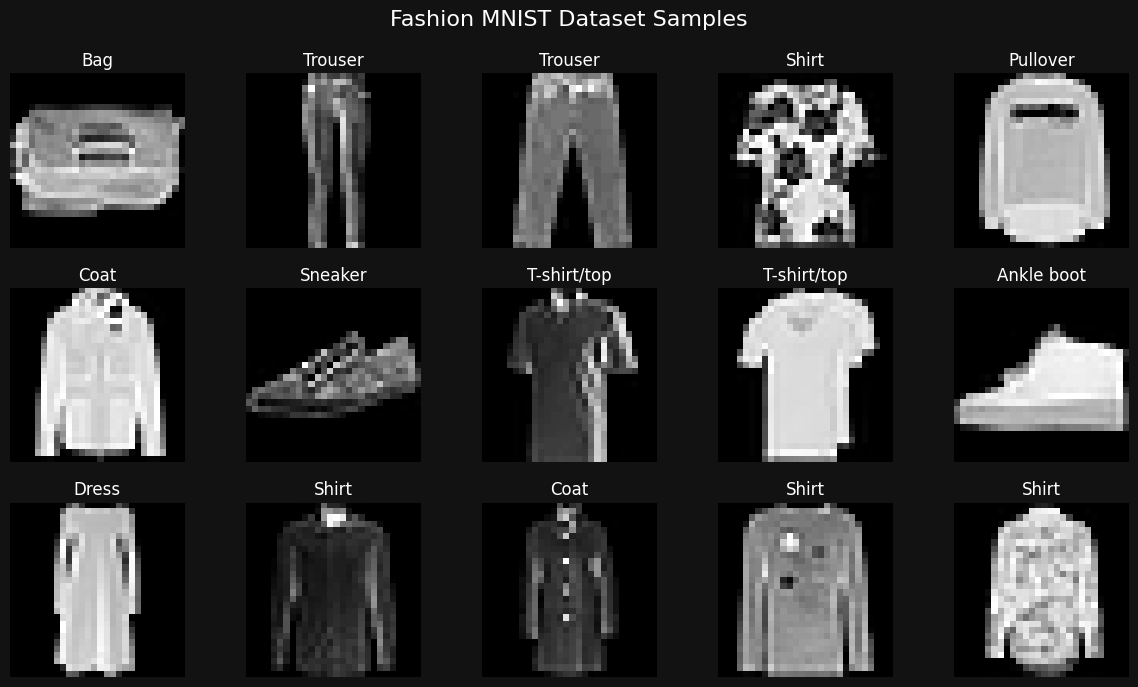


Feature Extraction Note for Slide 2:
In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.


In [2]:
# ==========================================
# 1. DATASET & VISUALIZATION
# ==========================================
# Load Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_ds = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

classes = train_ds.classes

# Generate a grid of examples for your presentation slide
def show_dataset_examples():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 5, figsize=(12, 7))
    fig.suptitle('Fashion MNIST Dataset Samples', fontsize=16, color='white')
    for i, ax in enumerate(axes.flat):
        img = images[i].numpy().squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[i]], color='white')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_dataset_examples()

print("\nFeature Extraction Note for Slide 2:")
print("In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.")

## 3. CNN Model

We train a Decision Tree classifier and perform hyperparameter tuning to find the best configuration.

In [3]:
# ==========================================
# 2. METHODS & HYPERPARAMETER TUNING
# ==========================================
# Define the CNN Architecture
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Function to run the tuning experiment
def run_experiments(learning_rates=[0.01, 0.001], epochs=4):
    results = []
    best_model_state = None
    best_acc = 0

    for lr in learning_rates:
        print(f"\nTraining CNN with Learning Rate: {lr}...")
        model = FashionCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        history = {'train_loss': [], 'val_acc': []}

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            # Validation phase
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(train_loader)
            epoch_acc = correct / total
            history['train_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc)
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Val Acc: {epoch_acc:.4f}")

        final_acc = history['val_acc'][-1]
        results.append({'LR': lr, 'Final_Accuracy': final_acc, 'History': history})

        # Save the best model for the confusion matrix later
        if final_acc > best_acc:
            best_acc = final_acc
            best_model_state = model.state_dict()

    # Load best weights into a final model object
    best_model = FashionCNN().to(device)
    best_model.load_state_dict(best_model_state)

    return results, best_model

# Execute the tuning loop (This will take a minute or two to run)
tuning_results, best_model = run_experiments(learning_rates=[0.01, 0.001], epochs=4)


Training CNN with Learning Rate: 0.01...
  Epoch 1/4 - Loss: 0.5562, Val Acc: 0.8483
  Epoch 2/4 - Loss: 0.4136, Val Acc: 0.8590
  Epoch 3/4 - Loss: 0.3870, Val Acc: 0.8628
  Epoch 4/4 - Loss: 0.3712, Val Acc: 0.8679

Training CNN with Learning Rate: 0.001...
  Epoch 1/4 - Loss: 0.5786, Val Acc: 0.8582
  Epoch 2/4 - Loss: 0.3789, Val Acc: 0.8760
  Epoch 3/4 - Loss: 0.3273, Val Acc: 0.8858
  Epoch 4/4 - Loss: 0.2976, Val Acc: 0.8931


## 4. K-Nearest Neighbors (KNN)

In this section, we apply the KNN algorithm and tune the value of K to improve performance.

In [4]:
# ==========================================
# 2B. KNN METHOD & HYPERPARAMETER TUNING
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Flatten and normalize the data for sklearn models
X_train_flat = train_ds.data.numpy().reshape(-1, 784) / 255.0
X_test_flat  = val_ds.data.numpy().reshape(-1, 784)   / 255.0
y_train_flat = train_ds.targets.numpy()
y_test_flat  = val_ds.targets.numpy()

# Use a stratified subset (KNN is slow on 60k samples)
from sklearn.model_selection import train_test_split
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat, y_train_flat,
    train_size=10000, stratify=y_train_flat, random_state=42
)
X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test_flat, y_test_flat,
    train_size=2000, stratify=y_test_flat, random_state=42
)

# Baseline KNN (no tuning)
knn_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    KNeighborsClassifier(n_neighbors=5)
)
knn_baseline.fit(X_train_sub, y_train_sub)
knn_base_pred = knn_baseline.predict(X_test_sub)
knn_base_acc  = accuracy_score(y_test_sub, knn_base_pred)
knn_base_f1   = f1_score(y_test_sub, knn_base_pred, average='weighted')
print(f"Baseline KNN — Accuracy: {knn_base_acc*100:.2f}%  F1: {knn_base_f1*100:.2f}%")

# GridSearchCV — Best KNN with PCA Pipeline
param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9],
    'kneighborsclassifier__metric':      ['euclidean', 'manhattan']
}

model_knn = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    KNeighborsClassifier()
)

grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, verbose=2)
grid_knn.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (KNN): {grid_knn.best_params_}")

print("\nAll CV results:")
for mean, std, param in zip(grid_knn.cv_results_['mean_test_score'],
                             grid_knn.cv_results_['std_test_score'],
                             grid_knn.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

# Evaluate best KNN
best_knn_model = grid_knn.best_estimator_
y_pred_knn     = best_knn_model.predict(X_test_sub)
best_knn_acc   = accuracy_score(y_test_sub, y_pred_knn)
best_knn_f1    = f1_score(y_test_sub, y_pred_knn, average='weighted')
print(f"\nBest KNN — Accuracy: {best_knn_acc*100:.2f}%  F1: {best_knn_f1*100:.2f}%")

Baseline KNN — Accuracy: 80.85%  F1: 81.13%
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   1.9s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   1.0s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   0.6s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighb

## 5. Support Vector Machine (SVM)

We train SVM models with different kernels and tune their parameters to achieve optimal results.

In [5]:
# ==========================================
# 2C. SVM METHODS & HYPERPARAMETER TUNING
# ==========================================
from sklearn.svm import SVC

# ── Baseline SVM Models ──────────────────────────────────
rbf_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='rbf', gamma=0.005, C=5)
)
rbf_baseline.fit(X_train_sub, y_train_sub)
rbf_base_pred = rbf_baseline.predict(X_test_sub)
rbf_base_acc  = accuracy_score(y_test_sub, rbf_base_pred)
rbf_base_f1   = f1_score(y_test_sub, rbf_base_pred, average='weighted')
print(f"Baseline SVM RBF  — Accuracy: {rbf_base_acc*100:.2f}%  F1: {rbf_base_f1*100:.2f}%")

poly_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='poly', degree=3, C=1)
)
poly_baseline.fit(X_train_sub, y_train_sub)
poly_base_pred = poly_baseline.predict(X_test_sub)
poly_base_acc  = accuracy_score(y_test_sub, poly_base_pred)
poly_base_f1   = f1_score(y_test_sub, poly_base_pred, average='weighted')
print(f"Baseline SVM Poly — Accuracy: {poly_base_acc*100:.2f}%  F1: {poly_base_f1*100:.2f}%")

# ── GridSearchCV — Best RBF SVM ───────────────────────────
param_grid_rbf = {
    'svc__C':     [1, 5, 10],
    'svc__gamma': [0.0005, 0.001, 0.005]
}

model_rbf = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='rbf', class_weight='balanced')
)

grid_rbf = GridSearchCV(model_rbf, param_grid_rbf, cv=5, verbose=2)
grid_rbf.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (RBF): {grid_rbf.best_params_}")
for mean, std, param in zip(grid_rbf.cv_results_['mean_test_score'],
                             grid_rbf.cv_results_['std_test_score'],
                             grid_rbf.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

best_rbf_model = grid_rbf.best_estimator_
y_pred_rbf     = best_rbf_model.predict(X_test_sub)
best_rbf_acc   = accuracy_score(y_test_sub, y_pred_rbf)
best_rbf_f1    = f1_score(y_test_sub, y_pred_rbf, average='weighted')
print(f"\nBest SVM RBF — Accuracy: {best_rbf_acc*100:.2f}%  F1: {best_rbf_f1*100:.2f}%")

# ── GridSearchCV — Best Polynomial SVM ───────────────────
param_grid_poly = {
    'svc__C':      [0.1, 1, 5, 10],
    'svc__degree': [2, 3, 4],
    'svc__gamma':  ['scale', 'auto']
}

model_poly = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='poly', class_weight='balanced')
)

grid_poly = GridSearchCV(model_poly, param_grid_poly, cv=5, verbose=2)
grid_poly.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (Polynomial): {grid_poly.best_params_}")
for mean, std, param in zip(grid_poly.cv_results_['mean_test_score'],
                             grid_poly.cv_results_['std_test_score'],
                             grid_poly.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

best_poly_model = grid_poly.best_estimator_
y_pred_poly     = best_poly_model.predict(X_test_sub)
best_poly_acc   = accuracy_score(y_test_sub, y_pred_poly)
best_poly_f1    = f1_score(y_test_sub, y_pred_poly, average='weighted')
print(f"\nBest SVM Poly — Accuracy: {best_poly_acc*100:.2f}%  F1: {best_poly_f1*100:.2f}%")

Baseline SVM RBF  — Accuracy: 86.80%  F1: 86.80%
Baseline SVM Poly — Accuracy: 79.95%  F1: 81.45%
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   6.9s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.6s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   8.3s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.7s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.6s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.7s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.3s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.7s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.3s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.2s
[CV] END .......................

## 6. Helper Functions

Reusable functions are defined here to simplify evaluation and visualization.

In [6]:
# ==========================================
# 2D. REUSABLE HELPER FUNCTIONS
# ==========================================

def evaluate_sklearn_model(model, X_test, y_test, class_names, model_name="Model"):
    """
    Evaluate a trained sklearn model: prints accuracy, F1,
    classification report, and plots a confusion matrix.
    """
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='weighted')

    print(f"── {model_name} ──────────────────────────────────────")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', color='white', fontsize=16)
    plt.xlabel('Predicted Label', color='white')
    plt.ylabel('True Label', color='white')
    plt.xticks(rotation=45)
    plt.show()

    return acc, f1


def build_sklearn_pipeline(classifier, n_components=100):
    """
    Build a PCA + classifier pipeline.
    Parameters:
        classifier   : any sklearn classifier instance
        n_components : number of PCA components
    Returns:
        sklearn Pipeline object
    """
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    return make_pipeline(pca, classifier)

## 7. Preliminary Results

We visualize and compare the performance of different models.


--- Summary of Hyperparameter Tuning ---


,Learning Rate,Validation Accuracy
0,0.010,0.8679
1,0.001,0.8931


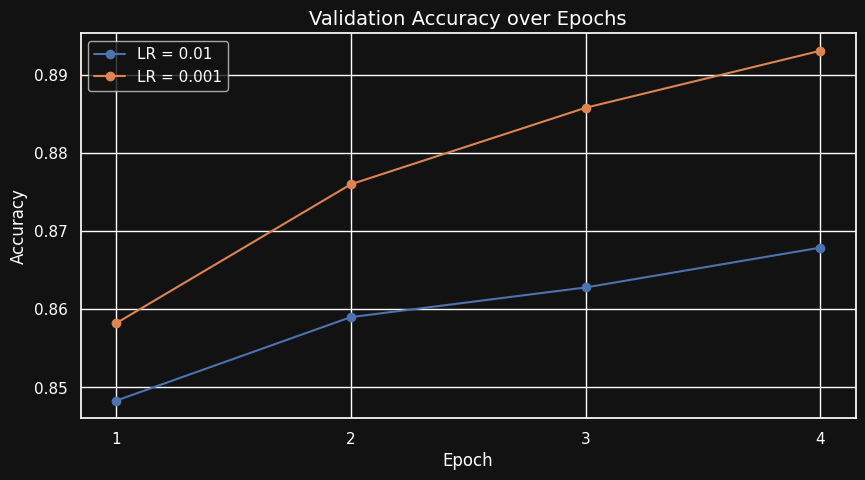

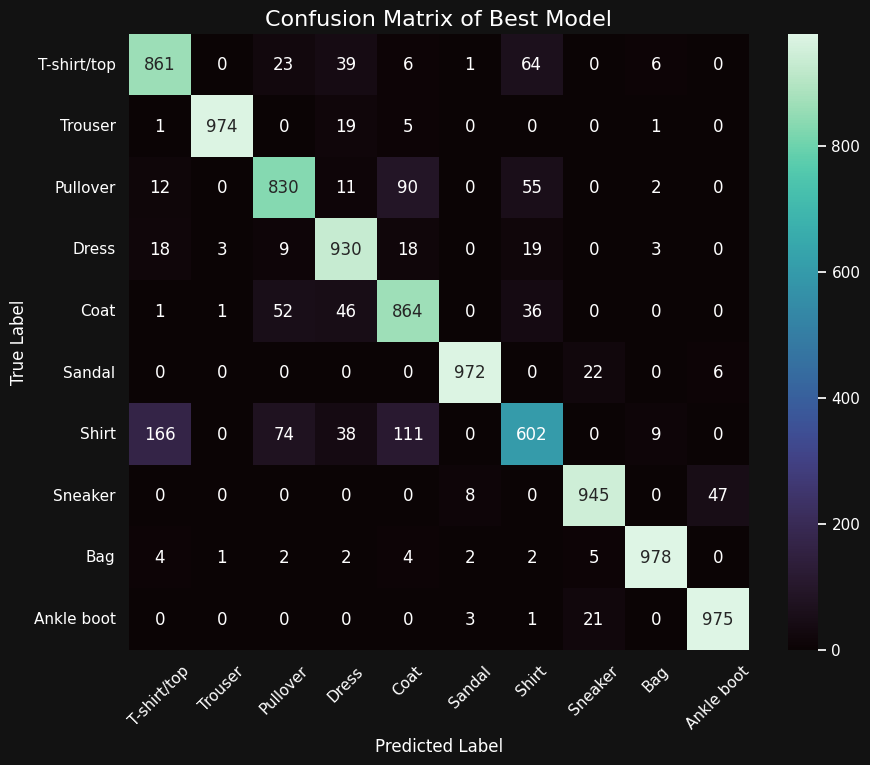


--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.83      0.83      1000
       Dress       0.86      0.93      0.89      1000
        Coat       0.79      0.86      0.82      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.77      0.60      0.68      1000
     Sneaker       0.95      0.94      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

── Best KNN ──────────────────────────────────────
  Accuracy : 81.05%
  F1 Score : 81.27%
              precision    recall  f1-score   support

 T-shirt/top       0.66      0.80      0.72       200
     Trous

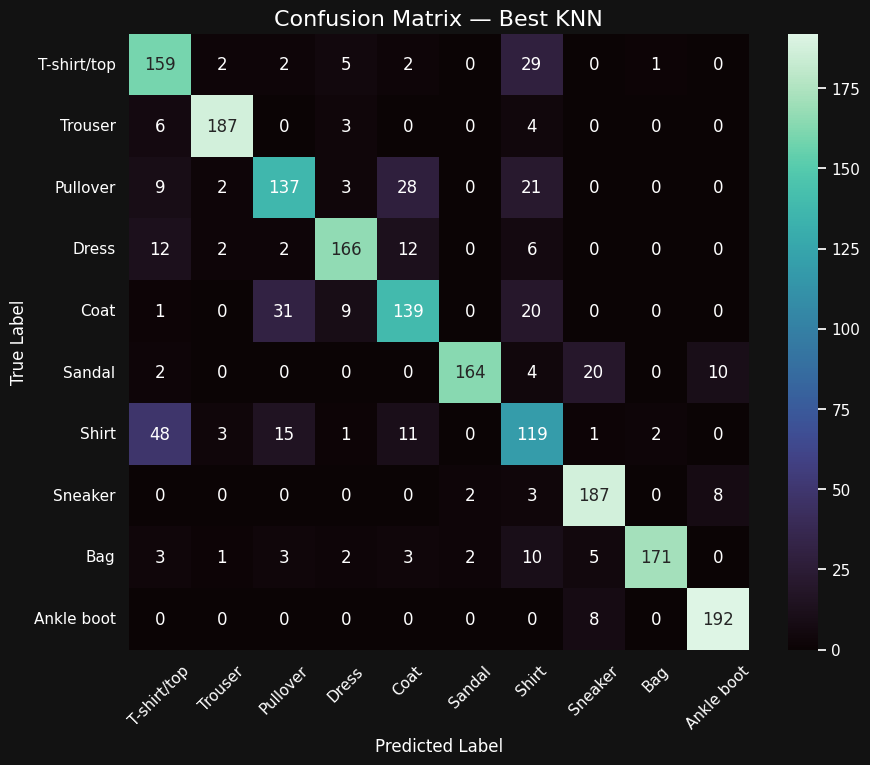

── Best SVM RBF ──────────────────────────────────────
  Accuracy : 86.80%
  F1 Score : 86.80%
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.82      0.82       200
     Trouser       0.99      0.95      0.97       200
    Pullover       0.73      0.72      0.73       200
       Dress       0.87      0.92      0.89       200
        Coat       0.78      0.78      0.78       200
      Sandal       0.95      0.97      0.96       200
       Shirt       0.66      0.66      0.66       200
     Sneaker       0.95      0.95      0.95       200
         Bag       0.96      0.96      0.96       200
  Ankle boot       0.96      0.95      0.96       200

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



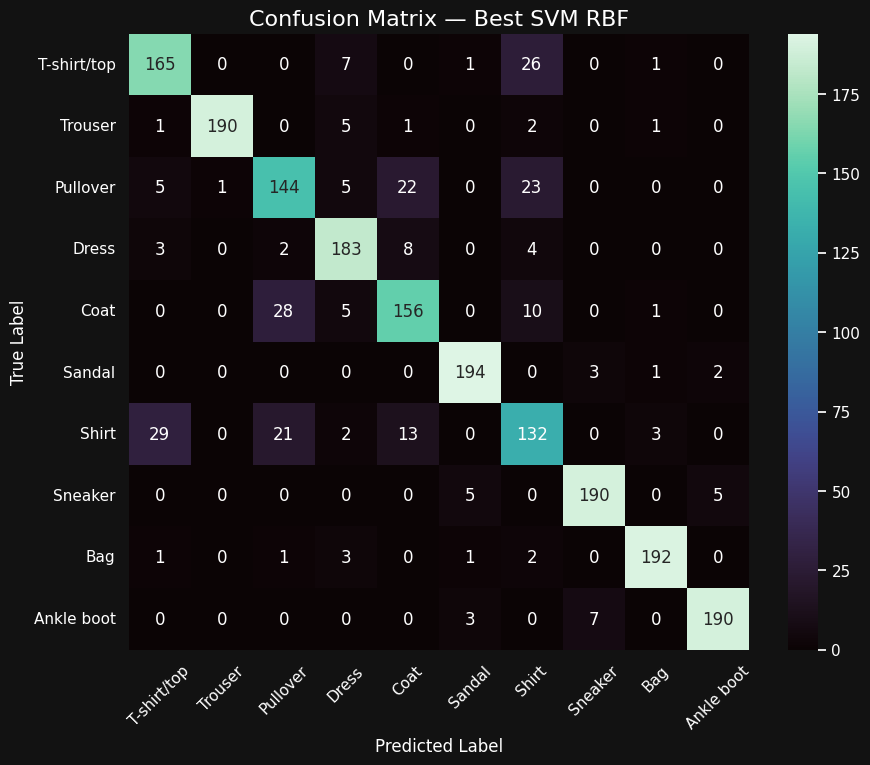

── Best SVM Polynomial ──────────────────────────────────────
  Accuracy : 85.85%
  F1 Score : 86.00%
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.82      0.81       200
     Trouser       0.99      0.95      0.97       200
    Pullover       0.76      0.69      0.73       200
       Dress       0.88      0.89      0.88       200
        Coat       0.78      0.77      0.77       200
      Sandal       0.97      0.94      0.95       200
       Shirt       0.61      0.69      0.65       200
     Sneaker       0.91      0.95      0.93       200
         Bag       0.96      0.93      0.95       200
  Ankle boot       0.97      0.94      0.96       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



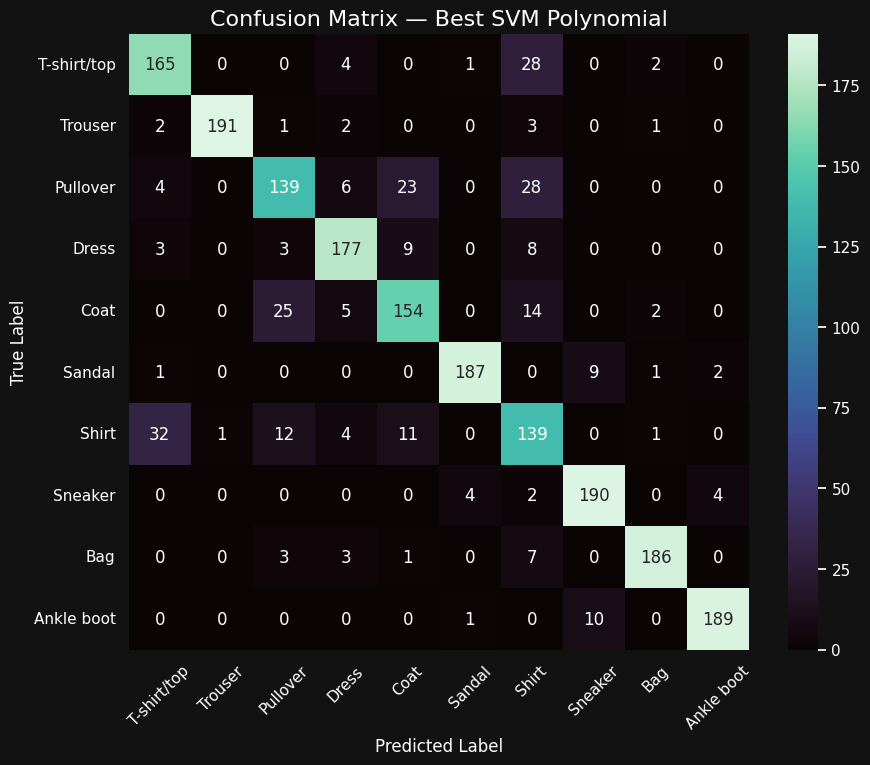

(0.8585, 0.8600106392262744)

In [7]:
# ==========================================
# 3. PRELIMINARY RESULTS (VISUALIZATIONS)
# ==========================================

# Slide 5: Hyperparameter Tuning Results
print("\n--- Summary of Hyperparameter Tuning ---")
df_results = pd.DataFrame([{'Learning Rate': r['LR'], 'Validation Accuracy': r['Final_Accuracy']} for r in tuning_results])
display(df_results)

# Plotting the Training Curves
plt.figure(figsize=(10, 5))
for res in tuning_results:
    plt.plot(res['History']['val_acc'], marker='o', label=f"LR = {res['LR']}")
plt.title('Validation Accuracy over Epochs', color='white', fontsize=14)
plt.xlabel('Epoch', color='white')
plt.ylabel('Accuracy', color='white')
plt.xticks(range(4), [1, 2, 3, 4])
plt.legend()
plt.show()

# Slide 6 & 7: Error Analysis (Confusion Matrix)
def evaluate_best_model(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix Plot
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    # Using a cool blue/purple colormap that fits the dark theme perfectly
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix of Best Model', color='white', fontsize=16)
    plt.xlabel('Predicted Label', color='white')
    plt.ylabel('True Label', color='white')
    plt.xticks(rotation=45)
    plt.show()

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

# CNN confusion matrix
evaluate_best_model(best_model)

# KNN, SVM — use the reusable helper (see section 2D)
evaluate_sklearn_model(best_knn_model,  X_test_sub, y_test_sub, classes, "Best KNN")
evaluate_sklearn_model(best_rbf_model,  X_test_sub, y_test_sub, classes, "Best SVM RBF")
evaluate_sklearn_model(best_poly_model, X_test_sub, y_test_sub, classes, "Best SVM Polynomial")

## 8. Final Testing

The best models are evaluated on the test dataset to measure their generalization performance.

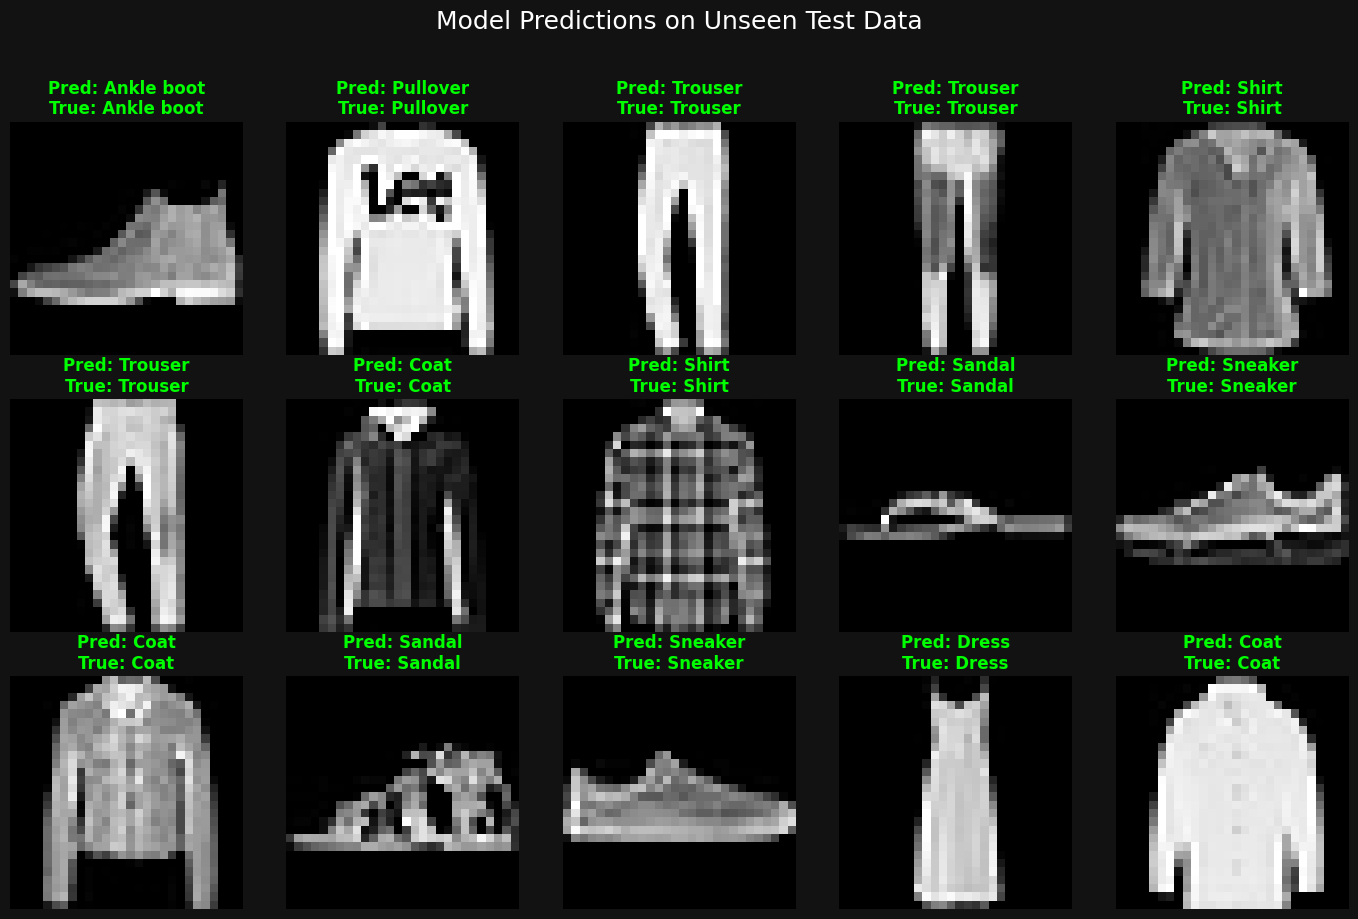


--- Batch Test Results ---
Correct Predictions: 57 / 64
Batch Accuracy: 89.06%


In [8]:
# ==========================================
# 4. FINAL TESTING & VISUAL INFERENCE
# ==========================================

def test_and_visualize(model, test_loader, num_images=15):
    # Grab a single batch of unseen test images
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images_device, labels_device = images.to(device), labels.to(device)

    # Set model to evaluation mode and get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

    # Move data back to CPU for plotting
    images = images.cpu()
    predicted = predicted.cpu()
    labels = labels.cpu()

    # Set up the visualization
    fig, axes = plt.subplots(3, 5, figsize=(14, 9))
    fig.suptitle('Model Predictions on Unseen Test Data', fontsize=18, color='white', y=1.02)

    for i, ax in enumerate(axes.flat):
        if i >= num_images:
            break

        img = images[i].numpy().squeeze()
        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]

        # Color coding: Neon Green for Correct, Bright Red for Incorrect
        text_color = '#00FF00' if true_label == pred_label else '#FF3333'

        ax.imshow(img, cmap='gray')
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=text_color, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and print the accuracy for this specific sample batch
    correct = (predicted == labels).sum().item()
    total = len(labels)
    print(f"\n--- Batch Test Results ---")
    print(f"Correct Predictions: {correct} / {total}")
    print(f"Batch Accuracy: {(correct/total)*100:.2f}%")

# Run the test using your best_model from the previous cell
test_and_visualize(best_model, val_loader)

## 9. Final Comparison and Conclusion

All models are compared, and the best-performing method is identified based on accuracy and other metrics.

In [9]:
# ==========================================
# 5. SUMMARY — ALL METHODS COMPARISON
# ==========================================

best_cnn_acc = max(r['Final_Accuracy'] for r in tuning_results)
best_cnn_lr  = max(tuning_results, key=lambda r: r['Final_Accuracy'])['LR']

summary = pd.DataFrame({
    "Method": [
        "CNN (best LR)",
        "KNN Baseline",
        "KNN (GridSearchCV)",
        "SVM RBF Baseline",
        "SVM Poly Baseline",
        "SVM RBF (GridSearchCV)",
        "SVM Poly (GridSearchCV)",
    ],
    "Key Params": [
        f"LR={best_cnn_lr}",
        "k=5, euclidean",
        str(grid_knn.best_params_),
        "C=5, gamma=0.005",
        "C=1, degree=3",
        str(grid_rbf.best_params_),
        str(grid_poly.best_params_),
    ],
    "Accuracy (%)": [
        round(best_cnn_acc*100, 2),
        round(knn_base_acc*100, 2),
        round(best_knn_acc*100, 2),
        round(rbf_base_acc*100, 2),
        round(poly_base_acc*100, 2),
        round(best_rbf_acc*100, 2),
        round(best_poly_acc*100, 2),
    ],
    "F1 Score (%)": [
        round(best_cnn_acc*100, 2),
        round(knn_base_f1*100,  2),
        round(best_knn_f1*100,  2),
        round(rbf_base_f1*100,  2),
        round(poly_base_f1*100, 2),
        round(best_rbf_f1*100,  2),
        round(best_poly_f1*100, 2),
    ]
})

print("── All Methods Comparison ───────────────────────────────")
display(summary)
best_idx = summary["Accuracy (%)"].idxmax()
print(f"\nBest overall: {summary.loc[best_idx, 'Method']} — {summary.loc[best_idx, 'Accuracy (%)']}%")

── All Methods Comparison ───────────────────────────────


,Method,Key Params,Accuracy (%),F1 Score (%)
0,CNN (best LR),LR=0.001,89.31,89.31
1,KNN Baseline,"k=5, euclidean",80.85,81.13
2,KNN (GridSearchCV),"{'kneighborsclassifier__metric': 'manhattan', ...",81.05,81.27
3,SVM RBF Baseline,"C=5, gamma=0.005",86.80,86.80
4,SVM Poly Baseline,"C=1, degree=3",79.95,81.45
5,SVM RBF (GridSearchCV),"{'svc__C': 5, 'svc__gamma': 0.005}",86.80,86.80
6,SVM Poly (GridSearchCV),"{'svc__C': 1, 'svc__degree': 2, 'svc__gamma': ...",85.85,86.00



Best overall: CNN (best LR) — 89.31%


## 10. Save Preprocessed Datasets

In this section, we save the PCA-reduced feature arrays that were generated
during preprocessing. These files represent the preprocessed version of the
Fashion-MNIST dataset used for training and evaluating the KNN and SVM models.

The following files are saved:
- `X_train_pca.npy` — Training features after PCA reduction (10,000 × 100)
- `X_test_pca.npy`  — Test features after PCA reduction (2,000 × 100)
- `y_train.npy`     — Training labels (10,000,)
- `y_test.npy`      — Test labels (2,000,)

> Note: PCA was fitted on the training subset and applied to both train and
> test sets. The raw Fashion-MNIST images are not included as they are
> automatically downloaded via `torchvision` when running the notebook.

In [10]:
# ==========================================
# 6. SAVE PREPROCESSED DATASETS
# ==========================================
import numpy as np

# Get the PCA object from the best KNN pipeline
pca = best_knn_model.named_steps['pca']

# Transform and save
X_train_pca = pca.transform(X_train_sub)
X_test_pca  = pca.transform(X_test_sub)

np.save("X_train_pca.npy", X_train_pca)
np.save("X_test_pca.npy",  X_test_pca)
np.save("y_train.npy", y_train_sub)
np.save("y_test.npy",  y_test_sub)

print("Saved:")
print(f"  X_train_pca.npy — shape: {X_train_pca.shape}")
print(f"  X_test_pca.npy  — shape: {X_test_pca.shape}")
print(f"  y_train.npy     — shape: {y_train_sub.shape}")
print(f"  y_test.npy      — shape: {y_test_sub.shape}")

Saved:
  X_train_pca.npy — shape: (10000, 100)
  X_test_pca.npy  — shape: (2000, 100)
  y_train.npy     — shape: (10000,)
  y_test.npy      — shape: (2000,)
